# PHẦN 4 – THỰC NGHIỆM NHẬN DIỆN KÝ TỰ BIỂN SỐ

## So sánh Pixel/HOG với KNN/SVM trên quy trình đánh giá thống nhất

- Kiểm tra và làm sạch dữ liệu trước khi huấn luyện.
- Dùng một pipeline tiền xử lý chung.
- Khảo sát tham số Gaussian Blur, HOG, KNN và SVM.
- Giữ một **final test set cố định**.
- Chọn mô hình bằng repeated validation trên development set.
- Xem augmentation như một hyperparameter, không quyết định bằng test.
- So sánh bốn pipeline:
  - Pixel + KNN
  - Pixel + SVM
  - HOG + KNN
  - HOG + SVM
- Đánh giá Accuracy, Macro Precision, Macro Recall, Macro F1, tốc độ và độ ổn định.
- Phân tích lỗi theo ký tự và theo nguồn biển số.
- Lưu model, scaler, metadata và các báo cáo CSV.


## 1. Mục tiêu, giả thuyết và tiêu chí thành công

### Vấn đề

Nhận diện chữ cái và chữ số từ các ảnh ký tự đã được tách khỏi biển số xe thực tế.

### Giả thuyết

1. **HOG** sẽ ổn định hơn pixel thô vì mô tả hướng cạnh và cấu trúc nét ký tự.
2. **SVM-RBF** có thể phân tách tốt hơn KNN đối với các ký tự gần giống nhau.
3. Augmentation nhẹ có thể cải thiện khả năng tổng quát hóa, nhưng có thể gây hại nếu tạo quá nhiều biến thể từ số ít ảnh thật.

### Tiêu chí thành công

- Cấu hình cuối được chọn bằng repeated validation, không chọn bằng final test.
- Final test không chứa ảnh augmentation.
- Macro F1 và Accuracy cao hơn majority-class baseline.
- Kết quả được báo cáo cùng độ lệch chuẩn và mức bao phủ lớp.
- Các lớp không xuất hiện trong final test được ghi rõ là chưa đánh giá đầy đủ.


## 2. Import và cấu hình


In [121]:
from pathlib import Path
from collections import Counter
from time import perf_counter
import hashlib
import json
import re

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_DIR = Path.cwd()
CHAR_DIR = PROJECT_DIR / "data" / "char_images"
MODEL_DIR = PROJECT_DIR / "model_data"
LABELS_FILE = MODEL_DIR / "labels.csv"
REPORT_DIR = MODEL_DIR / "experiment_reports"

CHAR_SIZE = (20, 30)  # OpenCV: (width, height)
BLUR_KERNEL = 3

TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20
FINAL_TEST_SEED = 2026
CV_SEEDS = [7, 21, 42, 84, 99]
MIN_VALID_CV_FOLDS = 3

K_VALUES = [1, 3, 5, 7]
C_VALUES = [0.1, 1.0, 10.0]
GAMMA_VALUES = [0.001, 0.01, 0.1]
HOG_BINS_VALUES = [6, 9, 12]

AUGMENT_OPTIONS = [False, True]
AUGMENT_TARGET_PER_CLASS = 10
MAX_AUGMENTATIONS_PER_IMAGE = 3

MIN_IMAGES_PER_CLASS_WARNING = 10
MIN_SOURCES_PER_CLASS_WARNING = 3

STRICT_DATA_VALIDATION = True
DROP_EXACT_DUPLICATES = True

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("LABELS_FILE:", LABELS_FILE)
print("LABELS tồn tại:", LABELS_FILE.exists())


PROJECT_DIR: f:\HocTap\xulyanh_thigiac\main\nh-n-bi-n-s-xe-main
LABELS_FILE: f:\HocTap\xulyanh_thigiac\main\nh-n-bi-n-s-xe-main\model_data\labels.csv
LABELS tồn tại: True


## 3. Quét dataset và kiểm tra nhãn

Notebook chỉ sử dụng các ảnh:

- Có trong `labels.csv`.
- Đường dẫn tồn tại.
- Có đúng một nhãn thuộc `0-9` hoặc `A-Z`.
- OpenCV đọc được.

Các ảnh `char_*` chưa được gán nhãn sẽ được xuất ra `unlabeled_images.csv`.


In [122]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp"}
LABEL_PATTERN = re.compile(r"^[0-9A-Z]$")


def normalize_path_text(value):
    return str(value).strip().replace("\\", "/")


def normalize_label(value):
    if pd.isna(value):
        return ""

    text = str(value).strip().upper()

    # Trường hợp pandas đọc số thành 1.0, 2.0...
    if re.fullmatch(r"\d\.0", text):
        text = text[0]

    return text


def resolve_image_path(raw_path):
    raw = normalize_path_text(raw_path)
    path = Path(raw)

    candidates = [
        path,
        PROJECT_DIR / path,
        LABELS_FILE.parent / path,
        CHAR_DIR / path,
    ]

    for candidate in candidates:
        if candidate.exists() and candidate.is_file():
            return candidate.resolve()

    return None


def scan_character_images():
    if not CHAR_DIR.exists():
        return []

    return sorted(
        path.resolve()
        for path in CHAR_DIR.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
        and path.stem.lower().startswith("char_")
    )


def load_labels_table():
    if not LABELS_FILE.exists():
        raise FileNotFoundError(
            f"Không tìm thấy {LABELS_FILE}. "
            "Hãy đặt labels.csv trong model_data."
        )

    df = pd.read_csv(LABELS_FILE)

    required_columns = {"image_path", "label"}
    if not required_columns.issubset(df.columns):
        raise ValueError(
            "labels.csv phải có ít nhất hai cột: image_path và label"
        )

    df = df.copy()
    df["image_path"] = df["image_path"].map(normalize_path_text)
    df["label_clean"] = df["label"].map(normalize_label)
    df["resolved_path"] = df["image_path"].map(resolve_image_path)
    df["valid_label"] = df["label_clean"].map(
        lambda value: bool(LABEL_PATTERN.fullmatch(value))
    )
    df["file_exists"] = df["resolved_path"].notna()

    return df


raw_labels_df = load_labels_table()
all_scanned_images = scan_character_images()

print("Số ảnh char_* quét được:", len(all_scanned_images))
print("Số dòng labels.csv:", len(raw_labels_df))


Số ảnh char_* quét được: 129
Số dòng labels.csv: 129


In [123]:
valid_rows = raw_labels_df[
    raw_labels_df["valid_label"]
    & raw_labels_df["file_exists"]
].copy()

invalid_label_rows = raw_labels_df[
    ~raw_labels_df["valid_label"]
].copy()

missing_path_rows = raw_labels_df[
    ~raw_labels_df["file_exists"]
].copy()

labeled_paths = set(valid_rows["resolved_path"])
unlabeled_paths = [
    path
    for path in all_scanned_images
    if path not in labeled_paths
]

unlabeled_export = pd.DataFrame({
    "image_path": [
        path.relative_to(PROJECT_DIR).as_posix()
        if PROJECT_DIR in path.parents
        else path.as_posix()
        for path in unlabeled_paths
    ],
    "label": "",
})

unlabeled_export.to_csv(
    REPORT_DIR / "unlabeled_images.csv",
    index=False,
    encoding="utf-8",
)

audit_summary = pd.DataFrame({
    "Hạng mục": [
        "Ảnh char_* quét được",
        "Dòng trong labels.csv",
        "Mẫu đủ nhãn và đường dẫn",
        "Ảnh chưa có nhãn",
        "Dòng nhãn rỗng/sai",
        "Dòng sai đường dẫn",
    ],
    "Số lượng": [
        len(all_scanned_images),
        len(raw_labels_df),
        len(valid_rows),
        len(unlabeled_paths),
        len(invalid_label_rows),
        len(missing_path_rows),
    ],
})

display(audit_summary)

if len(invalid_label_rows):
    display(Markdown("### Dòng nhãn không hợp lệ"))
    display(invalid_label_rows[["image_path", "label"]].head(30))

if len(missing_path_rows):
    display(Markdown("### Dòng sai đường dẫn"))
    display(missing_path_rows[["image_path", "label"]].head(30))

if len(unlabeled_export):
    display(Markdown(
        f"### Có {len(unlabeled_export)} ảnh chưa được gán nhãn\n"
        f"Đã xuất: `{REPORT_DIR / 'unlabeled_images.csv'}`"
    ))
    display(unlabeled_export.head(30))

if STRICT_DATA_VALIDATION:
    problems = []

    if len(invalid_label_rows):
        problems.append(
            f"{len(invalid_label_rows)} dòng nhãn không hợp lệ"
        )

    if len(missing_path_rows):
        problems.append(
            f"{len(missing_path_rows)} dòng sai đường dẫn"
        )

    if len(unlabeled_export):
        problems.append(
            f"{len(unlabeled_export)} ảnh char_* chưa có nhãn"
        )

    if problems:
        raise RuntimeError(
            "Dataset chưa vượt qua kiểm tra: "
            + "; ".join(problems)
            + ". Hãy sửa labels.csv rồi Run All lại."
        )

print("Dataset đã vượt qua kiểm tra nhãn và đường dẫn.")


,Hạng mục,Số lượng
0,Ảnh char_* quét được,129
1,Dòng trong labels.csv,129
2,Mẫu đủ nhãn và đường dẫn,129
3,Ảnh chưa có nhãn,0
4,Dòng nhãn rỗng/sai,0
5,Dòng sai đường dẫn,0


Dataset đã vượt qua kiểm tra nhãn và đường dẫn.


## 4. Pipeline tiền xử lý chung

Mọi mô hình đều dùng chính xác cùng pipeline:

1. Grayscale.
2. Resize về `20 × 30`.
3. Gaussian Blur.
4. Otsu Threshold.
5. Chuẩn hóa ký tự trắng trên nền đen.


In [124]:
def preprocess_binary(
    image_path,
    blur_kernel=BLUR_KERNEL,
    return_steps=False,
):
    gray = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE,
    )

    if gray is None:
        raise FileNotFoundError(
            f"Không đọc được ảnh: {image_path}"
        )

    resized = cv2.resize(gray, CHAR_SIZE)

    if blur_kernel == 1:
        blurred = resized.copy()
    else:
        if blur_kernel <= 0 or blur_kernel % 2 == 0:
            raise ValueError(
                "blur_kernel phải là số lẻ dương: 1, 3, 5..."
            )

        blurred = cv2.GaussianBlur(
            resized,
            (blur_kernel, blur_kernel),
            0,
        )

    threshold_value, binary = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU,
    )

    inverted = False
    if np.mean(binary) > 127:
        binary = cv2.bitwise_not(binary)
        inverted = True

    if return_steps:
        return binary, {
            "Ảnh gốc": gray,
            "Resize 20x30": resized,
            f"Gaussian Blur {blur_kernel}x{blur_kernel}": blurred,
            "Otsu + nền đen": binary,
            "Otsu threshold": float(threshold_value),
            "Đã đảo ảnh": inverted,
        }

    return binary


## 5. Khảo sát tham số Gaussian Blur

Ba giá trị được minh họa:

- `1`: không blur.
- `3`: blur nhẹ, cấu hình mặc định.
- `5`: blur mạnh hơn, có nguy cơ mất nét mảnh.

Phần này nhằm quan sát ảnh hưởng lên ảnh trung gian; cấu hình train cố định dùng `3 × 3`.


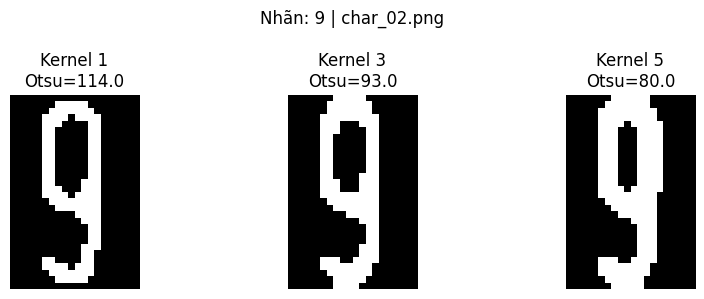

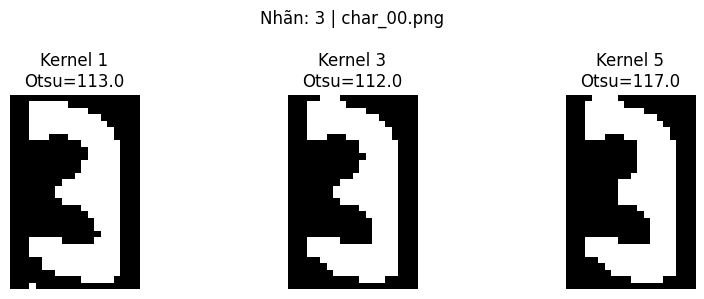

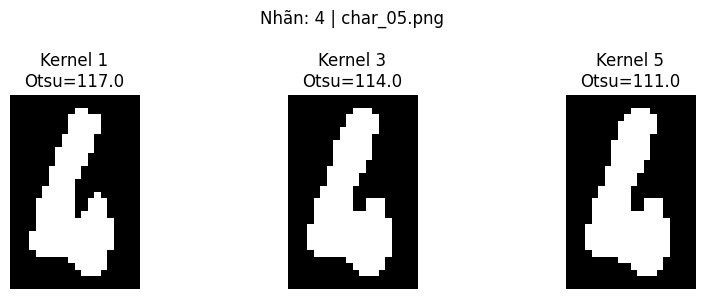

In [125]:
preview_rows = valid_rows.sample(
    n=min(3, len(valid_rows)),
    random_state=FINAL_TEST_SEED,
)

for _, row in preview_rows.iterrows():
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))

    for ax, kernel in zip(axes, [1, 3, 5]):
        binary, steps = preprocess_binary(
            row["resolved_path"],
            blur_kernel=kernel,
            return_steps=True,
        )

        ax.imshow(binary, cmap="gray")
        ax.set_title(
            f"Kernel {kernel}\n"
            f"Otsu={steps['Otsu threshold']:.1f}"
        )
        ax.axis("off")

    plt.suptitle(
        f"Nhãn: {row['label_clean']} | "
        f"{Path(row['resolved_path']).name}"
    )
    plt.tight_layout()
    plt.show()


## 6. Tạo dataset và xác định nguồn biển số

Nếu `labels.csv` có cột `source_id`, notebook ưu tiên dùng cột đó.

Nếu không có, `source_id` được suy ra từ thư mục đầu tiên bên dưới `data/char_images`.


In [126]:
def infer_source_id(path):
    path = Path(path)

    try:
        relative = path.relative_to(CHAR_DIR.resolve())

        if len(relative.parts) >= 2:
            return relative.parts[0]
    except ValueError:
        pass

    return path.parent.name


dataset_df = valid_rows[[
    "image_path",
    "label_clean",
    "resolved_path",
]].rename(columns={"label_clean": "label"}).copy()

if "source_id" in raw_labels_df.columns:
    source_map = (
        raw_labels_df
        .set_index("image_path")["source_id"]
        .to_dict()
    )

    dataset_df["source_id"] = dataset_df["image_path"].map(
        lambda path: str(source_map.get(path, "")).strip()
    )

    missing_source = dataset_df["source_id"] == ""
    dataset_df.loc[missing_source, "source_id"] = (
        dataset_df.loc[
            missing_source,
            "resolved_path",
        ].map(infer_source_id)
    )
else:
    dataset_df["source_id"] = dataset_df[
        "resolved_path"
    ].map(infer_source_id)

dataset_df["label_code"] = dataset_df["label"].map(ord)

print("Tổng mẫu trước khử trùng:", len(dataset_df))
print("Số lớp:", dataset_df["label"].nunique())
print("Số nguồn:", dataset_df["source_id"].nunique())

display(dataset_df.head())


Tổng mẫu trước khử trùng: 129
Số lớp: 19
Số nguồn: 16


,image_path,label,resolved_path,source_id,label_code
0,data/char_images/Dieu_0108/char_00.png,5,F:\HocTap\xulyanh_thigiac\main\nh-n-bi-n-s-xe-...,Dieu_0108,53
1,data/char_images/Dieu_0108/char_01.png,1,F:\HocTap\xulyanh_thigiac\main\nh-n-bi-n-s-xe-...,Dieu_0108,49
2,data/char_images/Dieu_0108/char_02.png,K,F:\HocTap\xulyanh_thigiac\main\nh-n-bi-n-s-xe-...,Dieu_0108,75
3,data/char_images/Dieu_0108/char_03.png,2,F:\HocTap\xulyanh_thigiac\main\nh-n-bi-n-s-xe-...,Dieu_0108,50
4,data/char_images/Dieu_0108/char_04.png,7,F:\HocTap\xulyanh_thigiac\main\nh-n-bi-n-s-xe-...,Dieu_0108,55


## 7. Kiểm tra ảnh trùng và nhãn mâu thuẫn


In [127]:
def normalized_image_hash(path):
    binary = preprocess_binary(path)
    return hashlib.sha1(binary.tobytes()).hexdigest()


dataset_df["image_hash"] = dataset_df["resolved_path"].map(
    normalized_image_hash
)

duplicate_rows = (
    dataset_df
    .groupby("image_hash")
    .filter(lambda group: len(group) > 1)
    .sort_values("image_hash")
)

conflicting_duplicates = (
    duplicate_rows
    .groupby("image_hash")
    .filter(lambda group: group["label"].nunique() > 1)
)

print("Số dòng thuộc nhóm ảnh trùng:", len(duplicate_rows))
print("Số dòng ảnh trùng nhưng khác nhãn:", len(conflicting_duplicates))

if len(conflicting_duplicates):
    display(conflicting_duplicates[[
        "image_path",
        "label",
        "source_id",
        "image_hash",
    ]])

    raise RuntimeError(
        "Có ảnh giống nhau nhưng được gán nhãn khác nhau. "
        "Hãy sửa labels.csv trước khi train."
    )

if DROP_EXACT_DUPLICATES:
    before_dedup = len(dataset_df)

    duplicate_export = dataset_df[
        dataset_df.duplicated(
            subset=["image_hash"],
            keep="first",
        )
    ].copy()

    duplicate_export.to_csv(
        REPORT_DIR / "removed_exact_duplicates.csv",
        index=False,
        encoding="utf-8",
    )

    dataset_df = (
        dataset_df
        .drop_duplicates(
            subset=["image_hash"],
            keep="first",
        )
        .copy()
    )

    print(
        "Đã bỏ số ảnh trùng tuyệt đối:",
        before_dedup - len(dataset_df),
    )

print("Tổng mẫu sau khử trùng:", len(dataset_df))


Số dòng thuộc nhóm ảnh trùng: 0
Số dòng ảnh trùng nhưng khác nhãn: 0
Đã bỏ số ảnh trùng tuyệt đối: 0
Tổng mẫu sau khử trùng: 129


## 8. Phân bố lớp và số nguồn của từng lớp

Số ảnh nhiều nhưng đều đến từ một biển số vẫn chưa đủ để đánh giá tổng quát hóa. Vì vậy notebook báo cáo cả:

- Số ảnh thật.
- Số `source_id` khác nhau.


,Nhãn,Số ảnh thật,Số nguồn,Cảnh báo
0,0,22,15,
1,1,15,11,
2,2,13,10,
3,3,9,6,Ít ảnh;
4,4,6,5,Ít ảnh;
5,5,18,13,
6,6,8,6,Ít ảnh;
7,7,6,4,Ít ảnh;
8,8,5,5,Ít ảnh;
9,9,11,10,


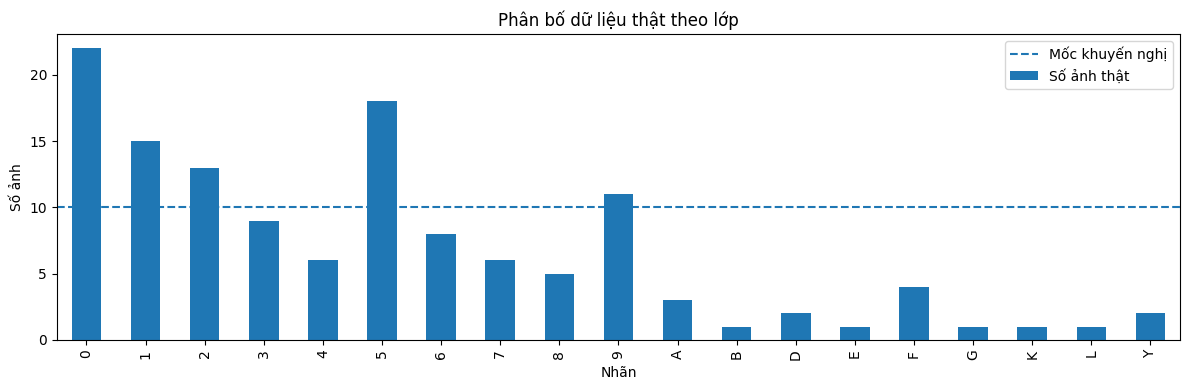

**Cảnh báo:** Các lớp sau vẫn còn ít ảnh hoặc ít nguồn. Kết quả của chúng cần được diễn giải thận trọng.

,Nhãn,Số ảnh thật,Số nguồn,Cảnh báo
3,3,9,6,Ít ảnh;
4,4,6,5,Ít ảnh;
6,6,8,6,Ít ảnh;
7,7,6,4,Ít ảnh;
8,8,5,5,Ít ảnh;
10,A,3,3,Ít ảnh;
11,B,1,1,Ít ảnh; Ít nguồn;
12,D,2,2,Ít ảnh; Ít nguồn;
13,E,1,1,Ít ảnh; Ít nguồn;
14,F,4,4,Ít ảnh;


In [128]:
class_distribution = (
    dataset_df
    .groupby("label")
    .agg(
        So_anh=("label", "size"),
        So_nguon=("source_id", "nunique"),
    )
    .reset_index()
    .rename(columns={
        "label": "Nhãn",
        "So_anh": "Số ảnh thật",
        "So_nguon": "Số nguồn",
    })
    .sort_values("Nhãn")
)

class_distribution["Cảnh báo"] = ""

class_distribution.loc[
    class_distribution["Số ảnh thật"]
    < MIN_IMAGES_PER_CLASS_WARNING,
    "Cảnh báo",
] += "Ít ảnh; "

class_distribution.loc[
    class_distribution["Số nguồn"]
    < MIN_SOURCES_PER_CLASS_WARNING,
    "Cảnh báo",
] += "Ít nguồn; "

display(class_distribution)

class_distribution.to_csv(
    REPORT_DIR / "class_distribution.csv",
    index=False,
    encoding="utf-8",
)

class_distribution.plot(
    kind="bar",
    x="Nhãn",
    y="Số ảnh thật",
    legend=False,
    figsize=(12, 4),
)

plt.axhline(
    MIN_IMAGES_PER_CLASS_WARNING,
    linestyle="--",
    label="Mốc khuyến nghị",
)
plt.title("Phân bố dữ liệu thật theo lớp")
plt.xlabel("Nhãn")
plt.ylabel("Số ảnh")
plt.legend()
plt.tight_layout()
plt.show()

warning_classes = class_distribution[
    class_distribution["Cảnh báo"] != ""
]

if len(warning_classes):
    display(Markdown(
        "**Cảnh báo:** Các lớp sau vẫn còn ít ảnh hoặc ít nguồn. "
        "Kết quả của chúng cần được diễn giải thận trọng."
    ))
    display(warning_classes)


## 9. Ảnh trung gian


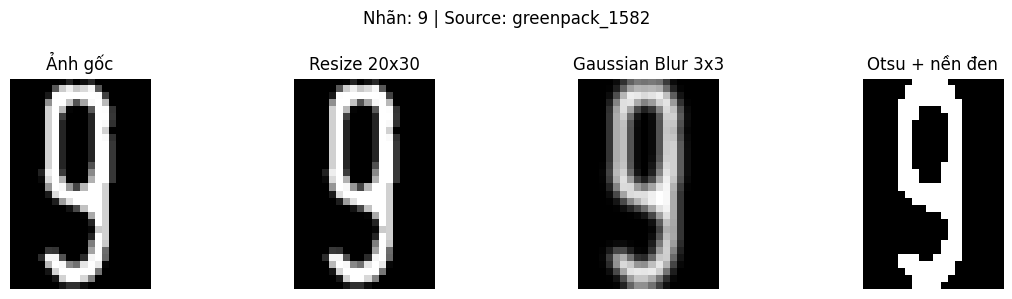

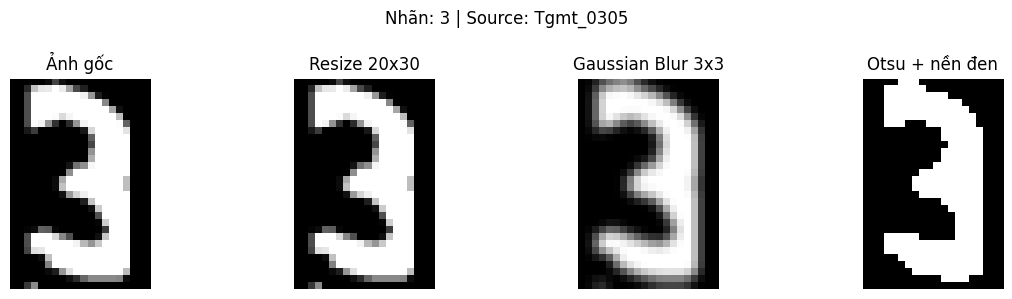

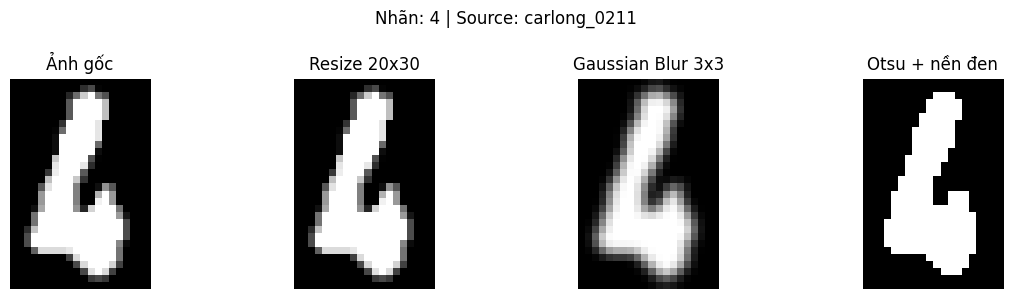

In [129]:
sample_rows = dataset_df.sample(
    n=min(3, len(dataset_df)),
    random_state=FINAL_TEST_SEED,
)

for _, row in sample_rows.iterrows():
    binary, steps = preprocess_binary(
        row["resolved_path"],
        return_steps=True,
    )

    images = [
        steps["Ảnh gốc"],
        steps["Resize 20x30"],
        steps[f"Gaussian Blur {BLUR_KERNEL}x{BLUR_KERNEL}"],
        steps["Otsu + nền đen"],
    ]

    titles = [
        "Ảnh gốc",
        "Resize 20x30",
        f"Gaussian Blur {BLUR_KERNEL}x{BLUR_KERNEL}",
        "Otsu + nền đen",
    ]

    fig, axes = plt.subplots(1, 4, figsize=(12, 3))

    for ax, image, title in zip(axes, images, titles):
        ax.imshow(image, cmap="gray")
        ax.set_title(title)
        ax.axis("off")

    plt.suptitle(
        f"Nhãn: {row['label']} | "
        f"Source: {row['source_id']}"
    )
    plt.tight_layout()
    plt.show()


## 10. Đặc trưng Pixel và HOG

HOG được khảo sát với ba giá trị số bins:

- HOG6
- HOG9
- HOG12


In [130]:
FEATURE_CONFIGS = {
    "PIXEL": {
        "family": "PIXEL",
        "kind": "pixel",
        "nbins": None,
    },
    "HOG6": {
        "family": "HOG",
        "kind": "hog",
        "nbins": 6,
    },
    "HOG9": {
        "family": "HOG",
        "kind": "hog",
        "nbins": 9,
    },
    "HOG12": {
        "family": "HOG",
        "kind": "hog",
        "nbins": 12,
    },
}


def make_hog_descriptor(nbins):
    return cv2.HOGDescriptor(
        _winSize=CHAR_SIZE,
        _blockSize=(10, 10),
        _blockStride=(5, 5),
        _cellSize=(5, 5),
        _nbins=int(nbins),
    )


def pixel_feature(binary):
    return (
        binary
        .reshape(-1)
        .astype(np.float32)
        / 255.0
    )


def hog_feature(binary, nbins):
    descriptor = make_hog_descriptor(
        nbins
    ).compute(binary)

    return (
        descriptor
        .reshape(-1)
        .astype(np.float32)
    )


def feature_matrix(binaries, feature_name):
    config = FEATURE_CONFIGS[feature_name]

    if config["kind"] == "pixel":
        rows = [
            pixel_feature(binary)
            for binary in binaries
        ]
    elif config["kind"] == "hog":
        rows = [
            hog_feature(
                binary,
                config["nbins"],
            )
            for binary in binaries
        ]
    else:
        raise ValueError(
            f"Feature không hỗ trợ: {feature_name}"
        )

    return np.asarray(rows, dtype=np.float32)


sample_zero = np.zeros(
    (CHAR_SIZE[1], CHAR_SIZE[0]),
    dtype=np.uint8,
)

FEATURE_DIMS = {}

for feature_name in FEATURE_CONFIGS:
    dimension = feature_matrix(
        [sample_zero],
        feature_name,
    ).shape[1]

    FEATURE_DIMS[feature_name] = int(dimension)
    print(feature_name, "số chiều:", dimension)


PIXEL số chiều: 600
HOG6 số chiều: 360
HOG9 số chiều: 540
HOG12 số chiều: 720


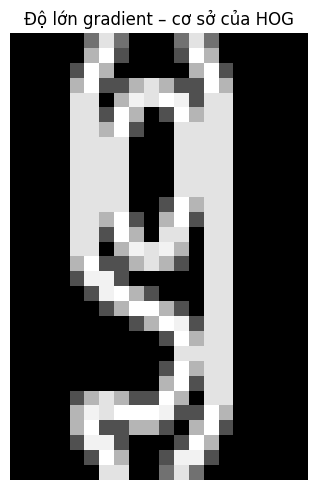

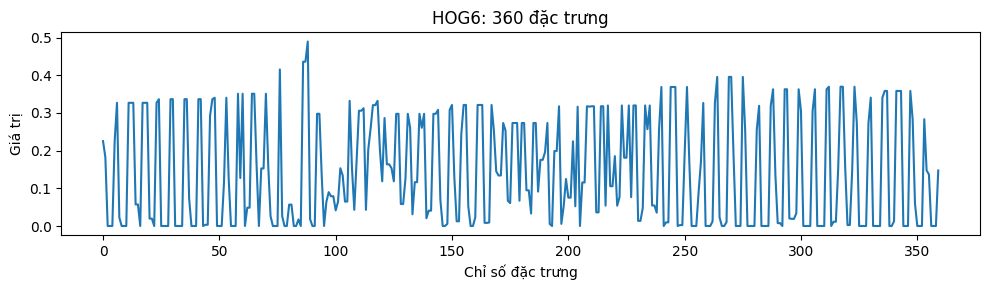

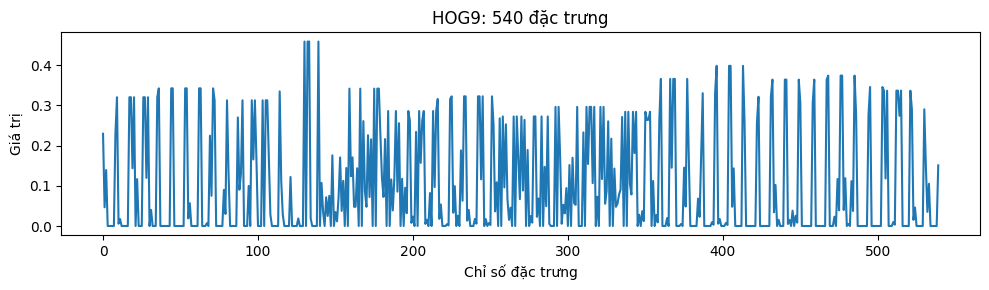

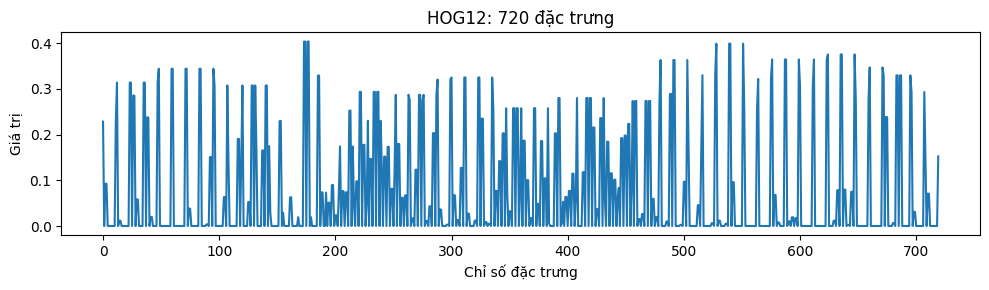

In [131]:
sample_binary = preprocess_binary(
    sample_rows.iloc[0]["resolved_path"]
)

gx = cv2.Sobel(sample_binary, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(sample_binary, cv2.CV_32F, 0, 1, ksize=3)
magnitude = cv2.magnitude(gx, gy)

plt.figure(figsize=(4, 5))
plt.imshow(magnitude, cmap="gray")
plt.title("Độ lớn gradient – cơ sở của HOG")
plt.axis("off")
plt.tight_layout()
plt.show()

for feature_name in ["HOG6", "HOG9", "HOG12"]:
    vector = feature_matrix(
        [sample_binary],
        feature_name,
    )[0]

    plt.figure(figsize=(10, 3))
    plt.plot(vector)
    plt.title(
        f"{feature_name}: {len(vector)} đặc trưng"
    )
    plt.xlabel("Chỉ số đặc trưng")
    plt.ylabel("Giá trị")
    plt.tight_layout()
    plt.show()


## 11. Chia Development và Final Test cố định

Final test được tạo một lần bằng `FINAL_TEST_SEED`.

Sau khi đã nhìn kết quả final test, không dùng nó để:

- Thay đổi HOG bins.
- Thay đổi K.
- Thay đổi C hoặc gamma.
- Bật/tắt augmentation.
- Chỉnh preprocessing.


In [132]:
def split_score(
    candidate_test,
    full_df,
    test_size,
):
    overall = (
        full_df["label"]
        .value_counts()
        .sort_index()
    )

    target = overall * test_size

    test_counts = (
        candidate_test["label"]
        .value_counts()
        .reindex(overall.index, fill_value=0)
    )

    train_counts = overall - test_counts

    distribution_error = np.mean(
        np.abs(test_counts - target)
        / (target + 1.0)
    )

    row_ratio_error = abs(
        len(candidate_test) / len(full_df)
        - test_size
    )

    # Không cho phép một lớp biến mất khỏi train.
    missing_train_penalty = (
        10000.0
        * int((train_counts == 0).sum())
    )

    source_counts = (
        full_df
        .groupby("label")["source_id"]
        .nunique()
        .reindex(overall.index, fill_value=0)
    )

    evaluable_labels = source_counts >= 2

    missing_test_penalty = (
        5.0
        * int(
            (
                (test_counts == 0)
                & evaluable_labels
            ).sum()
        )
    )

    return (
        distribution_error
        + row_ratio_error
        + missing_train_penalty
        + missing_test_penalty
    )


def best_group_holdout(
    df,
    test_size,
    seed,
    attempts=3000,
):
    groups = np.asarray(
        sorted(df["source_id"].unique())
    )

    if len(groups) < 4:
        raise ValueError(
            "Cần ít nhất 4 source_id để chia group-aware."
        )

    n_test_groups = int(
        round(len(groups) * test_size)
    )

    n_test_groups = min(
        max(1, n_test_groups),
        len(groups) - 1,
    )

    rng = np.random.default_rng(seed)
    best_split = None
    best_value = float("inf")

    for _ in range(attempts):
        selected_groups = set(
            rng.choice(
                groups,
                size=n_test_groups,
                replace=False,
            )
        )

        candidate_test = df[
            df["source_id"].isin(selected_groups)
        ]

        candidate_train = df[
            ~df["source_id"].isin(selected_groups)
        ]

        if candidate_test.empty or candidate_train.empty:
            continue

        value = split_score(
            candidate_test,
            df,
            test_size,
        )

        if value < best_value:
            best_value = value
            best_split = (
                candidate_train.index.to_numpy(),
                candidate_test.index.to_numpy(),
            )

    if best_split is None or best_value >= 10000:
        raise ValueError(
            "Không tìm được group split giữ đầy đủ lớp trong train. "
            "Cần bổ sung thêm source cho các lớp hiếm."
        )

    return best_split


development_idx, final_test_idx = best_group_holdout(
    dataset_df,
    TEST_SIZE,
    FINAL_TEST_SEED,
)

development_df = dataset_df.loc[
    development_idx
].copy()

final_test_df = dataset_df.loc[
    final_test_idx
].copy()

assert set(
    development_df["source_id"]
).isdisjoint(
    final_test_df["source_id"]
)

split_summary = pd.DataFrame({
    "Tập": ["Development", "Final test"],
    "Số mẫu": [
        len(development_df),
        len(final_test_df),
    ],
    "Số lớp": [
        development_df["label"].nunique(),
        final_test_df["label"].nunique(),
    ],
    "Số nguồn": [
        development_df["source_id"].nunique(),
        final_test_df["source_id"].nunique(),
    ],
})

display(split_summary)


,Tập,Số mẫu,Số lớp,Số nguồn
0,Development,106,19,13
1,Final test,23,13,3


In [133]:
def class_presence_table(*named_frames):
    all_labels = sorted(dataset_df["label"].unique())
    table = pd.DataFrame({"Nhãn": all_labels})

    for name, frame in named_frames:
        counts = frame["label"].value_counts()
        table[name] = (
            table["Nhãn"]
            .map(counts)
            .fillna(0)
            .astype(int)
        )

    return table


final_presence = class_presence_table(
    ("Development", development_df),
    ("Final test", final_test_df),
)

display(final_presence)

missing_final_test_classes = final_presence.loc[
    final_presence["Final test"] == 0,
    "Nhãn",
].tolist()

print(
    "Các lớp chưa xuất hiện trong final test:",
    missing_final_test_classes,
)

print(
    "Độ bao phủ lớp final test:",
    f"{final_test_df['label'].nunique()}/"
    f"{dataset_df['label'].nunique()}",
)


,Nhãn,Development,Final test
0,0,18,4
1,1,14,1
2,2,11,2
3,3,7,2
4,4,5,1
5,5,14,4
6,6,6,2
7,7,5,1
8,8,4,1
9,9,9,2


Các lớp chưa xuất hiện trong final test: ['B', 'D', 'E', 'G', 'K', 'L']
Độ bao phủ lớp final test: 13/19


## 12. Augmentation chỉ dành cho train fold

Augmentation được xem như một hyperparameter gồm hai lựa chọn:

- Không augmentation.
- Có augmentation nhẹ.

Validation và final test luôn chứa ảnh thật.


In [134]:
def augment_binary(binary, rng):
    height, width = binary.shape

    angle = float(rng.uniform(-4.0, 4.0))
    dx = float(rng.uniform(-1.0, 1.0))
    dy = float(rng.uniform(-1.0, 1.0))

    matrix = cv2.getRotationMatrix2D(
        (width / 2, height / 2),
        angle,
        1.0,
    )
    matrix[:, 2] += [dx, dy]

    augmented = cv2.warpAffine(
        binary,
        matrix,
        (width, height),
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )

    random_value = rng.random()

    if random_value < 0.12:
        kernel = np.ones((2, 2), dtype=np.uint8)
        augmented = cv2.dilate(
            augmented,
            kernel,
            iterations=1,
        )
    elif random_value < 0.24:
        kernel = np.ones((2, 2), dtype=np.uint8)
        augmented = cv2.erode(
            augmented,
            kernel,
            iterations=1,
        )

    _, augmented = cv2.threshold(
        augmented,
        127,
        255,
        cv2.THRESH_BINARY,
    )

    return augmented


def prepare_binary_samples(
    frame,
    use_augmentation=False,
    target_per_class=AUGMENT_TARGET_PER_CLASS,
    seed=42,
):
    rng = np.random.default_rng(seed)

    binaries = []
    labels = []
    source_ids = []
    augmented_flags = []
    row_indices = []

    rows_by_label = {}

    for row_index, row in frame.iterrows():
        binary = preprocess_binary(
            row["resolved_path"]
        )

        binaries.append(binary)
        labels.append(row["label_code"])
        source_ids.append(row["source_id"])
        augmented_flags.append(False)
        row_indices.append(row_index)

        rows_by_label.setdefault(
            row["label"],
            [],
        ).append((binary, row_index, row))

    if use_augmentation:
        for _, items in rows_by_label.items():
            current_count = len(items)
            needed = max(
                0,
                target_per_class - current_count,
            )

            generated_per_image = Counter()
            item_position = 0

            while needed > 0 and items:
                binary, row_index, row = (
                    items[
                        item_position % len(items)
                    ]
                )

                image_key = str(row["resolved_path"])

                if (
                    generated_per_image[image_key]
                    >= MAX_AUGMENTATIONS_PER_IMAGE
                ):
                    item_position += 1

                    all_reached_limit = all(
                        generated_per_image[
                            str(item_row["resolved_path"])
                        ]
                        >= MAX_AUGMENTATIONS_PER_IMAGE
                        for _, _, item_row in items
                    )

                    if all_reached_limit:
                        break

                    continue

                binaries.append(
                    augment_binary(binary, rng)
                )
                labels.append(row["label_code"])
                source_ids.append(row["source_id"])
                augmented_flags.append(True)
                row_indices.append(row_index)

                generated_per_image[image_key] += 1
                needed -= 1
                item_position += 1

    return {
        "binaries": binaries,
        "y": np.asarray(labels, dtype=np.int32),
        "source_ids": source_ids,
        "is_augmented": np.asarray(
            augmented_flags,
            dtype=bool,
        ),
        "row_indices": row_indices,
    }


## 13. Chuẩn hóa đặc trưng


In [135]:
def fit_scaler(X_train):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    std[std < 1e-8] = 1.0

    return (
        mean.astype(np.float32),
        std.astype(np.float32),
    )


def apply_scaler(X, mean, std):
    return (
        (X - mean) / std
    ).astype(np.float32)


## 14. Chỉ số đánh giá

Macro F1 được tính trên các lớp thật sự xuất hiện trong tập đánh giá.

Các lớp chỉ xuất hiện trong dự đoán sai vẫn được ghi riêng để phân tích false positive.


In [136]:
def classification_report_manual(
    y_true,
    y_pred,
    evaluated_labels=None,
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if evaluated_labels is None:
        evaluated_labels = sorted(set(y_true))

    rows = []

    for label in evaluated_labels:
        tp = int(np.sum(
            (y_true == label)
            & (y_pred == label)
        ))

        fp = int(np.sum(
            (y_true != label)
            & (y_pred == label)
        ))

        fn = int(np.sum(
            (y_true == label)
            & (y_pred != label)
        ))

        support = int(np.sum(y_true == label))

        precision = (
            tp / (tp + fp)
            if tp + fp else 0.0
        )

        recall = (
            tp / (tp + fn)
            if tp + fn else 0.0
        )

        f1 = (
            2 * precision * recall
            / (precision + recall)
            if precision + recall
            else 0.0
        )

        rows.append({
            "Nhãn": chr(label),
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1,
            "Support": support,
        })

    return pd.DataFrame(rows)


def summarize_predictions(
    y_true,
    y_pred,
    train_time=0.0,
    predict_time=0.0,
    total_dataset_classes=None,
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    evaluated_labels = sorted(set(y_true))

    report = classification_report_manual(
        y_true,
        y_pred,
        evaluated_labels=evaluated_labels,
    )

    predicted_only_labels = sorted(
        set(y_pred) - set(y_true)
    )

    validation_class_count = len(evaluated_labels)

    if total_dataset_classes is None:
        total_dataset_classes = validation_class_count

    class_coverage = (
        validation_class_count
        / total_dataset_classes
        if total_dataset_classes
        else 0.0
    )

    return {
        "Accuracy": float(
            np.mean(y_true == y_pred)
        ),
        "Macro Precision": float(
            report["Precision"].mean()
        ),
        "Macro Recall": float(
            report["Recall"].mean()
        ),
        "Macro F1": float(
            report["F1-score"].mean()
        ),
        "Đúng": int(
            np.sum(y_true == y_pred)
        ),
        "Sai": int(
            np.sum(y_true != y_pred)
        ),
        "Số lớp đánh giá": validation_class_count,
        "Độ bao phủ lớp": class_coverage,
        "Lớp chỉ xuất hiện ở dự đoán": ",".join(
            chr(label)
            for label in predicted_only_labels
        ),
        "Train time (s)": float(train_time),
        "Predict time (s)": float(predict_time),
        "Predict/mẫu (ms)": (
            float(
                predict_time
                / len(y_true)
                * 1000
            )
            if len(y_true)
            else 0.0
        ),
        "report": report,
    }


def confusion_matrix_manual(y_true, y_pred):
    labels = sorted(set(y_true) | set(y_pred))
    positions = {
        label: index
        for index, label in enumerate(labels)
    }

    matrix = np.zeros(
        (len(labels), len(labels)),
        dtype=int,
    )

    for true_label, predicted_label in zip(
        y_true,
        y_pred,
    ):
        matrix[
            positions[true_label],
            positions[predicted_label],
        ] += 1

    return labels, matrix


## 15. Huấn luyện KNN và SVM


In [137]:
def train_knn(X_train, y_train, k):
    model = cv2.ml.KNearest_create()
    model.setDefaultK(int(k))
    model.setIsClassifier(True)

    ok = model.train(
        X_train.astype(np.float32),
        cv2.ml.ROW_SAMPLE,
        y_train
        .astype(np.float32)
        .reshape(-1, 1),
    )

    if not ok:
        raise RuntimeError(
            "Huấn luyện KNN thất bại."
        )

    return model


def predict_knn(model, X, k):
    _, result, _, _ = model.findNearest(
        X.astype(np.float32),
        k=int(k),
    )

    return (
        result
        .reshape(-1)
        .astype(np.int32)
    )


def train_svm(
    X_train,
    y_train,
    C,
    gamma,
):
    model = cv2.ml.SVM_create()
    model.setType(cv2.ml.SVM_C_SVC)
    model.setKernel(cv2.ml.SVM_RBF)
    model.setC(float(C))
    model.setGamma(float(gamma))
    model.setTermCriteria(
        (
            cv2.TERM_CRITERIA_MAX_ITER
            + cv2.TERM_CRITERIA_EPS,
            5000,
            1e-6,
        )
    )

    ok = model.train(
        X_train.astype(np.float32),
        cv2.ml.ROW_SAMPLE,
        y_train.astype(np.int32),
    )

    if not ok:
        raise RuntimeError(
            "Huấn luyện SVM thất bại."
        )

    return model


def predict_svm(model, X):
    _, result = model.predict(
        X.astype(np.float32)
    )

    return (
        result
        .reshape(-1)
        .astype(np.int32)
    )


## 16. Repeated validation trên Development set

Với mỗi seed:

1. Chia development thành train fold và validation fold theo `source_id`.
2. Validation chỉ chứa ảnh thật.
3. Thử cả không augmentation và có augmentation.
4. Khảo sát:
   - KNN: `K = 1, 3, 5, 7`.
   - SVM: 9 tổ hợp `C × gamma`.
   - HOG: `6, 9, 12 bins`.


In [138]:
CV_VALIDATION_RATIO = (
    VALIDATION_SIZE
    / (1.0 - TEST_SIZE)
)

cv_rows = []
valid_fold_seeds = []
failed_fold_messages = []

total_dataset_classes = (
    dataset_df["label"].nunique()
)

for fold_seed in CV_SEEDS:
    try:
        train_idx, validation_idx = (
            best_group_holdout(
                development_df,
                CV_VALIDATION_RATIO,
                fold_seed,
            )
        )
    except ValueError as exc:
        failed_fold_messages.append(
            f"Seed {fold_seed}: {exc}"
        )
        continue

    fold_train_df = development_df.loc[
        train_idx
    ].copy()

    fold_validation_df = development_df.loc[
        validation_idx
    ].copy()

    assert set(
        fold_train_df["source_id"]
    ).isdisjoint(
        fold_validation_df["source_id"]
    )

    validation_samples = prepare_binary_samples(
        fold_validation_df,
        use_augmentation=False,
        seed=fold_seed,
    )

    valid_fold_seeds.append(fold_seed)

    for use_augmentation in AUGMENT_OPTIONS:
        train_samples = prepare_binary_samples(
            fold_train_df,
            use_augmentation=use_augmentation,
            target_per_class=AUGMENT_TARGET_PER_CLASS,
            seed=fold_seed,
        )

        for feature_name in FEATURE_CONFIGS:
            X_train_raw = feature_matrix(
                train_samples["binaries"],
                feature_name,
            )

            X_validation_raw = feature_matrix(
                validation_samples["binaries"],
                feature_name,
            )

            mean, std = fit_scaler(X_train_raw)

            X_train = apply_scaler(
                X_train_raw,
                mean,
                std,
            )

            X_validation = apply_scaler(
                X_validation_raw,
                mean,
                std,
            )

            for k in K_VALUES:
                if k > len(X_train):
                    continue

                start = perf_counter()

                model = train_knn(
                    X_train,
                    train_samples["y"],
                    k,
                )

                train_time = (
                    perf_counter() - start
                )

                start = perf_counter()

                predictions = predict_knn(
                    model,
                    X_validation,
                    k,
                )

                predict_time = (
                    perf_counter() - start
                )

                summary = summarize_predictions(
                    validation_samples["y"],
                    predictions,
                    train_time,
                    predict_time,
                    total_dataset_classes,
                )

                cv_rows.append({
                    "Seed": fold_seed,
                    "Feature": feature_name,
                    "Feature family": (
                        FEATURE_CONFIGS[
                            feature_name
                        ]["family"]
                    ),
                    "Feature dim": (
                        FEATURE_DIMS[
                            feature_name
                        ]
                    ),
                    "Model": "KNN",
                    "K": k,
                    "C": np.nan,
                    "Gamma": np.nan,
                    "Params": f"K={k}",
                    "Augmentation": (
                        use_augmentation
                    ),
                    "Train samples": (
                        len(train_samples["y"])
                    ),
                    "Validation samples": (
                        len(
                            validation_samples["y"]
                        )
                    ),
                    **{
                        key: value
                        for key, value
                        in summary.items()
                        if key != "report"
                    },
                })

            for C in C_VALUES:
                for gamma in GAMMA_VALUES:
                    start = perf_counter()

                    model = train_svm(
                        X_train,
                        train_samples["y"],
                        C,
                        gamma,
                    )

                    train_time = (
                        perf_counter() - start
                    )

                    start = perf_counter()

                    predictions = predict_svm(
                        model,
                        X_validation,
                    )

                    predict_time = (
                        perf_counter() - start
                    )

                    summary = summarize_predictions(
                        validation_samples["y"],
                        predictions,
                        train_time,
                        predict_time,
                        total_dataset_classes,
                    )

                    cv_rows.append({
                        "Seed": fold_seed,
                        "Feature": feature_name,
                        "Feature family": (
                            FEATURE_CONFIGS[
                                feature_name
                            ]["family"]
                        ),
                        "Feature dim": (
                            FEATURE_DIMS[
                                feature_name
                            ]
                        ),
                        "Model": "SVM",
                        "K": np.nan,
                        "C": C,
                        "Gamma": gamma,
                        "Params": (
                            f"C={C}, "
                            f"gamma={gamma}"
                        ),
                        "Augmentation": (
                            use_augmentation
                        ),
                        "Train samples": (
                            len(train_samples["y"])
                        ),
                        "Validation samples": (
                            len(
                                validation_samples["y"]
                            )
                        ),
                        **{
                            key: value
                            for key, value
                            in summary.items()
                            if key != "report"
                        },
                    })


if failed_fold_messages:
    display(Markdown(
        "### Các fold không tạo được\n"
        + "\n".join(
            f"- {message}"
            for message in failed_fold_messages
        )
    ))

if len(valid_fold_seeds) < MIN_VALID_CV_FOLDS:
    raise RuntimeError(
        f"Chỉ tạo được {len(valid_fold_seeds)} fold hợp lệ. "
        f"Cần ít nhất {MIN_VALID_CV_FOLDS}. "
        "Hãy bổ sung thêm source cho các lớp hiếm."
    )

cv_results = pd.DataFrame(cv_rows)

print("Các seed hợp lệ:", valid_fold_seeds)
print("Tổng lượt huấn luyện:", len(cv_results))
display(cv_results.head())


Các seed hợp lệ: [7, 21, 42, 84, 99]
Tổng lượt huấn luyện: 520


,Seed,Feature,Feature family,Feature dim,Model,K,C,Gamma,Params,Augmentation,...,Macro Recall,Macro F1,Đúng,Sai,Số lớp đánh giá,Độ bao phủ lớp,Lớp chỉ xuất hiện ở dự đoán,Train time (s),Predict time (s),Predict/mẫu (ms)
0,7,PIXEL,PIXEL,600,KNN,1.0,NaN,NaN,K=1,False,...,0.583333,0.544444,16,8,12,0.631579,L,0.000108,0.000284,0.011833
1,7,PIXEL,PIXEL,600,KNN,3.0,NaN,NaN,K=3,False,...,0.430556,0.369017,13,11,12,0.631579,,0.000125,0.000263,0.010971
2,7,PIXEL,PIXEL,600,KNN,5.0,NaN,NaN,K=5,False,...,0.486111,0.443519,15,9,12,0.631579,,0.000090,0.000211,0.008779
3,7,PIXEL,PIXEL,600,KNN,7.0,NaN,NaN,K=7,False,...,0.430556,0.370899,13,11,12,0.631579,,0.000074,0.000241,0.010042
4,7,PIXEL,PIXEL,600,SVM,NaN,0.1,0.001,"C=0.1, gamma=0.001",False,...,0.083333,0.018519,3,21,12,0.631579,,0.006476,0.000238,0.009925


## 17. Tổng hợp kết quả và chọn cấu hình

Quy tắc chọn:

1. Mean Macro F1 cao hơn.
2. Std Macro F1 thấp hơn.
3. Mean Accuracy cao hơn.
4. Std Accuracy thấp hơn.
5. Ưu tiên không augmentation nếu chất lượng hòa.
6. Feature ít chiều hơn.
7. Dự đoán nhanh hơn.

Final test không tham gia bước chọn này.


In [139]:
group_columns = [
    "Feature",
    "Feature family",
    "Feature dim",
    "Model",
    "K",
    "C",
    "Gamma",
    "Params",
    "Augmentation",
]

selection_summary = (
    cv_results
    .groupby(
        group_columns,
        dropna=False,
    )
    .agg(
        Fold_count=("Seed", "nunique"),
        Mean_Macro_F1=("Macro F1", "mean"),
        Std_Macro_F1=("Macro F1", "std"),
        Mean_Accuracy=("Accuracy", "mean"),
        Std_Accuracy=("Accuracy", "std"),
        Mean_Macro_Precision=(
            "Macro Precision",
            "mean",
        ),
        Mean_Macro_Recall=(
            "Macro Recall",
            "mean",
        ),
        Mean_Class_Coverage=(
            "Độ bao phủ lớp",
            "mean",
        ),
        Mean_Train_Time=(
            "Train time (s)",
            "mean",
        ),
        Mean_Predict_ms=(
            "Predict/mẫu (ms)",
            "mean",
        ),
    )
    .reset_index()
)

selection_summary[
    "Std_Macro_F1"
] = selection_summary[
    "Std_Macro_F1"
].fillna(0.0)

selection_summary[
    "Std_Accuracy"
] = selection_summary[
    "Std_Accuracy"
].fillna(0.0)

selection_summary = (
    selection_summary
    .sort_values(
        [
            "Mean_Macro_F1",
            "Std_Macro_F1",
            "Mean_Accuracy",
            "Std_Accuracy",
            "Augmentation",
            "Feature dim",
            "Mean_Predict_ms",
            "Feature",
            "Model",
            "Params",
        ],
        ascending=[
            False,
            True,
            False,
            True,
            True,
            True,
            True,
            True,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(
    selection_summary.head(25).style.format({
        "Mean_Macro_F1": "{:.4f}",
        "Std_Macro_F1": "{:.4f}",
        "Mean_Accuracy": "{:.4f}",
        "Std_Accuracy": "{:.4f}",
        "Mean_Macro_Precision": "{:.4f}",
        "Mean_Macro_Recall": "{:.4f}",
        "Mean_Class_Coverage": "{:.4f}",
        "Mean_Train_Time": "{:.6f}",
        "Mean_Predict_ms": "{:.4f}",
    })
)

selected_config = selection_summary.iloc[0]

display(Markdown("### Cấu hình được chọn bằng repeated validation"))
display(selected_config.to_frame(name="Giá trị"))


,Feature,Feature family,Feature dim,Model,K,C,Gamma,Params,Augmentation,Fold_count,Mean_Macro_F1,Std_Macro_F1,Mean_Accuracy,Std_Accuracy,Mean_Macro_Precision,Mean_Macro_Recall,Mean_Class_Coverage,Mean_Train_Time,Mean_Predict_ms
0,HOG6,HOG,360,KNN,3.000000,nan,nan,K=3,True,5,0.9833,0.0000,0.9583,0.0000,1.0000,0.9722,0.6316,0.000133,0.0155
1,HOG12,HOG,720,KNN,3.000000,nan,nan,K=3,True,5,0.9833,0.0000,0.9583,0.0000,1.0000,0.9722,0.6316,0.000195,0.0148
2,HOG9,HOG,540,KNN,3.000000,nan,nan,K=3,True,5,0.9452,0.0522,0.9417,0.0228,0.9583,0.9389,0.6316,0.000107,0.0129
3,HOG9,HOG,540,KNN,5.000000,nan,nan,K=5,True,5,0.9373,0.0646,0.9333,0.0373,0.9542,0.9306,0.6316,0.000108,0.0126
4,HOG6,HOG,360,KNN,5.000000,nan,nan,K=5,True,5,0.9094,0.0524,0.9167,0.0295,0.9250,0.9083,0.6316,0.000114,0.0143
5,HOG12,HOG,720,KNN,5.000000,nan,nan,K=5,True,5,0.9071,0.0426,0.9250,0.0186,0.9167,0.9056,0.6316,0.000182,0.0161
6,HOG9,HOG,540,SVM,nan,10.000000,0.001000,"C=10.0, gamma=0.001",False,5,0.9048,0.0000,0.9583,0.0000,0.8958,0.9167,0.6316,0.006395,0.0129
7,HOG12,HOG,720,SVM,nan,10.000000,0.001000,"C=10.0, gamma=0.001",False,5,0.9048,0.0000,0.9583,0.0000,0.8958,0.9167,0.6316,0.008422,0.0150
8,HOG12,HOG,720,SVM,nan,1.000000,0.001000,"C=1.0, gamma=0.001",True,5,0.9048,0.0000,0.9583,0.0000,0.8958,0.9167,0.6316,0.019934,0.0198
9,HOG12,HOG,720,SVM,nan,10.000000,0.001000,"C=10.0, gamma=0.001",True,5,0.9014,0.0075,0.9500,0.0186,0.8958,0.9111,0.6316,0.018163,0.0217


### Cấu hình được chọn bằng repeated validation

,Giá trị
Feature,HOG6
Feature family,HOG
Feature dim,360
Model,KNN
K,3.0
C,NaN
Gamma,NaN
Params,K=3
Augmentation,True
Fold_count,5


## 18. So sánh bốn pipeline trên Validation


In [140]:
best_four_validation = (
    selection_summary
    .groupby(
        ["Feature family", "Model"],
        as_index=False,
        group_keys=False,
    )
    .head(1)
    .copy()
)

display(
    best_four_validation[[
        "Feature family",
        "Feature",
        "Model",
        "Params",
        "Augmentation",
        "Mean_Macro_F1",
        "Std_Macro_F1",
        "Mean_Accuracy",
        "Mean_Class_Coverage",
    ]].style.format({
        "Mean_Macro_F1": "{:.4f}",
        "Std_Macro_F1": "{:.4f}",
        "Mean_Accuracy": "{:.4f}",
        "Mean_Class_Coverage": "{:.4f}",
    })
)


,Feature family,Feature,Model,Params,Augmentation,Mean_Macro_F1,Std_Macro_F1,Mean_Accuracy,Mean_Class_Coverage
0,HOG,HOG6,KNN,K=3,True,0.9833,0.0000,0.9583,0.6316
6,HOG,HOG9,SVM,"C=10.0, gamma=0.001",False,0.9048,0.0000,0.9583,0.6316
28,PIXEL,PIXEL,SVM,"C=10.0, gamma=0.001",True,0.6473,0.0160,0.7250,0.6316
33,PIXEL,PIXEL,KNN,K=3,True,0.5934,0.0796,0.6750,0.6316


## 19. Biểu đồ khảo sát KNN, SVM và HOG


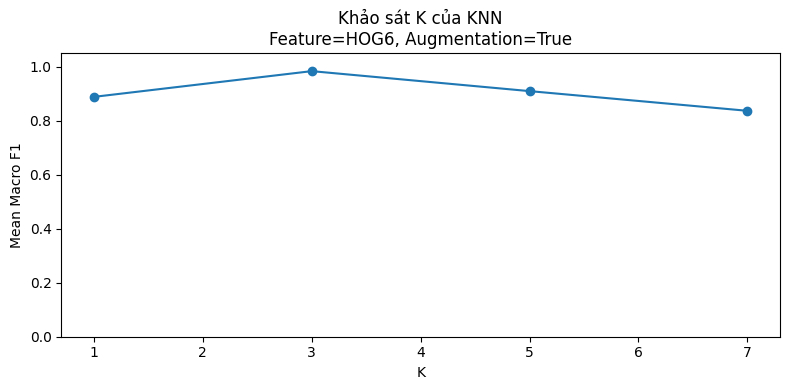

In [141]:
best_knn_row = (
    selection_summary[
        selection_summary["Model"] == "KNN"
    ]
    .iloc[0]
)

knn_sweep = selection_summary[
    (selection_summary["Model"] == "KNN")
    & (
        selection_summary["Feature"]
        == best_knn_row["Feature"]
    )
    & (
        selection_summary["Augmentation"]
        == best_knn_row["Augmentation"]
    )
].sort_values("K")

plt.figure(figsize=(8, 4))
plt.plot(
    knn_sweep["K"],
    knn_sweep["Mean_Macro_F1"],
    marker="o",
)
plt.title(
    "Khảo sát K của KNN\n"
    f"Feature={best_knn_row['Feature']}, "
    f"Augmentation={best_knn_row['Augmentation']}"
)
plt.xlabel("K")
plt.ylabel("Mean Macro F1")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


Gamma,0.001,0.010,0.100
C,,,
0.1,0.018519,0.018519,0.018519
1.0,0.506061,0.276984,0.018519
10.0,0.904762,0.373063,0.074786


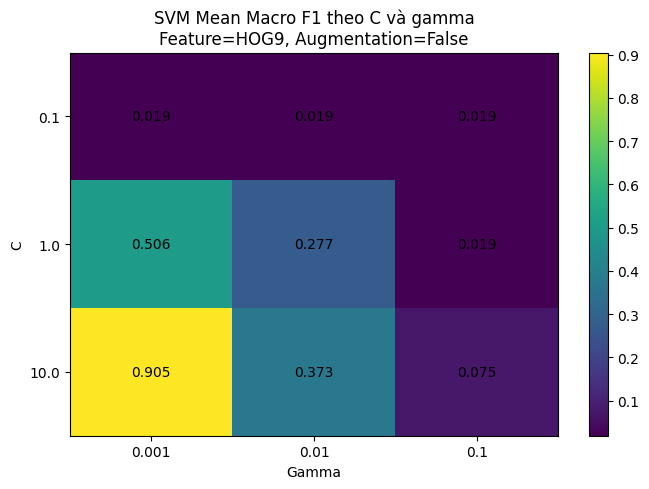

In [142]:
best_svm_row = (
    selection_summary[
        selection_summary["Model"] == "SVM"
    ]
    .iloc[0]
)

svm_sweep = selection_summary[
    (selection_summary["Model"] == "SVM")
    & (
        selection_summary["Feature"]
        == best_svm_row["Feature"]
    )
    & (
        selection_summary["Augmentation"]
        == best_svm_row["Augmentation"]
    )
].copy()

svm_pivot = svm_sweep.pivot(
    index="C",
    columns="Gamma",
    values="Mean_Macro_F1",
)

display(svm_pivot)

plt.figure(figsize=(7, 5))
plt.imshow(
    svm_pivot.values,
    aspect="auto",
)
plt.title(
    "SVM Mean Macro F1 theo C và gamma\n"
    f"Feature={best_svm_row['Feature']}, "
    f"Augmentation={best_svm_row['Augmentation']}"
)
plt.xlabel("Gamma")
plt.ylabel("C")
plt.xticks(
    range(len(svm_pivot.columns)),
    svm_pivot.columns,
)
plt.yticks(
    range(len(svm_pivot.index)),
    svm_pivot.index,
)
plt.colorbar()

for row_index in range(
    len(svm_pivot.index)
):
    for column_index in range(
        len(svm_pivot.columns)
    ):
        plt.text(
            column_index,
            row_index,
            f"{svm_pivot.iloc[row_index, column_index]:.3f}",
            ha="center",
            va="center",
        )

plt.tight_layout()
plt.show()


,Feature,Model,Params,Augmentation,Mean_Macro_F1,Std_Macro_F1
0,HOG6,KNN,K=3,True,0.9833,0.0000
1,HOG12,KNN,K=3,True,0.9833,0.0000
2,HOG9,KNN,K=3,True,0.9452,0.0522
6,HOG9,SVM,"C=10.0, gamma=0.001",False,0.9048,0.0000
7,HOG12,SVM,"C=10.0, gamma=0.001",False,0.9048,0.0000
17,HOG6,SVM,"C=1.0, gamma=0.001",True,0.8870,0.0243


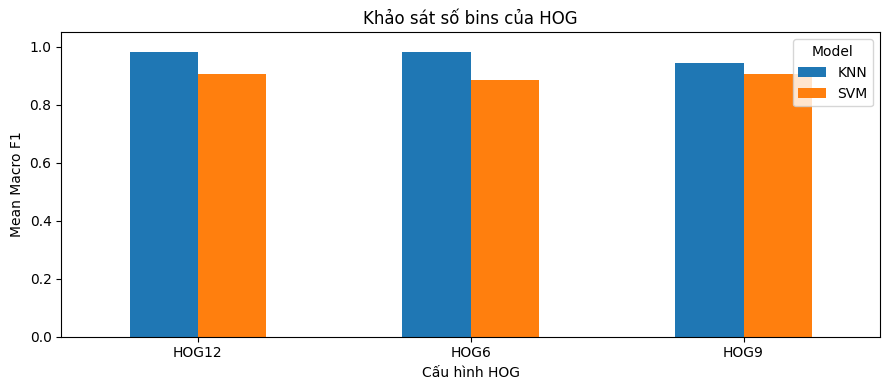

In [143]:
hog_sweep = (
    selection_summary[
        selection_summary[
            "Feature family"
        ] == "HOG"
    ]
    .groupby(
        ["Feature", "Model"],
        as_index=False,
        group_keys=False,
    )
    .head(1)
    .copy()
)

display(
    hog_sweep[[
        "Feature",
        "Model",
        "Params",
        "Augmentation",
        "Mean_Macro_F1",
        "Std_Macro_F1",
    ]].style.format({
        "Mean_Macro_F1": "{:.4f}",
        "Std_Macro_F1": "{:.4f}",
    })
)

hog_plot = hog_sweep.pivot(
    index="Feature",
    columns="Model",
    values="Mean_Macro_F1",
)

hog_plot.plot(
    kind="bar",
    figsize=(9, 4),
)

plt.title("Khảo sát số bins của HOG")
plt.xlabel("Cấu hình HOG")
plt.ylabel("Mean Macro F1")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 20. Ảnh hưởng của augmentation trên Validation

Không sử dụng final test để quyết định bật hay tắt augmentation.


In [144]:
augmentation_effect = (
    selection_summary
    .groupby("Augmentation")
    .agg(
        Best_Mean_Macro_F1=(
            "Mean_Macro_F1",
            "max",
        ),
        Mean_All_Configurations=(
            "Mean_Macro_F1",
            "mean",
        ),
    )
    .reset_index()
)

display(
    augmentation_effect.style.format({
        "Best_Mean_Macro_F1": "{:.4f}",
        "Mean_All_Configurations": "{:.4f}",
    })
)


,Augmentation,Best_Mean_Macro_F1,Mean_All_Configurations
0,False,0.9048,0.3387
1,True,0.9833,0.4511


## 21. Hàm huấn luyện một cấu hình trên Development và đánh giá Final Test


In [145]:
def row_to_config(row):
    model_name = str(row["Model"])

    config = {
        "feature": str(row["Feature"]),
        "feature_family": str(
            row["Feature family"]
        ),
        "feature_dim": int(
            row["Feature dim"]
        ),
        "model": model_name,
        "augmentation": bool(
            row["Augmentation"]
        ),
        "params_text": str(row["Params"]),
    }

    if model_name == "KNN":
        config["k"] = int(row["K"])
    else:
        config["C"] = float(row["C"])
        config["gamma"] = float(
            row["Gamma"]
        )

    return config


def train_and_evaluate_config(
    config,
    train_frame,
    test_frame,
    seed,
):
    train_samples = prepare_binary_samples(
        train_frame,
        use_augmentation=(
            config["augmentation"]
        ),
        target_per_class=(
            AUGMENT_TARGET_PER_CLASS
        ),
        seed=seed,
    )

    test_samples = prepare_binary_samples(
        test_frame,
        use_augmentation=False,
        seed=seed,
    )

    assert int(
        test_samples["is_augmented"].sum()
    ) == 0

    X_train_raw = feature_matrix(
        train_samples["binaries"],
        config["feature"],
    )

    X_test_raw = feature_matrix(
        test_samples["binaries"],
        config["feature"],
    )

    mean, std = fit_scaler(X_train_raw)

    X_train = apply_scaler(
        X_train_raw,
        mean,
        std,
    )

    X_test = apply_scaler(
        X_test_raw,
        mean,
        std,
    )

    start = perf_counter()

    if config["model"] == "KNN":
        model = train_knn(
            X_train,
            train_samples["y"],
            config["k"],
        )
    else:
        model = train_svm(
            X_train,
            train_samples["y"],
            config["C"],
            config["gamma"],
        )

    train_time = perf_counter() - start

    start = perf_counter()

    if config["model"] == "KNN":
        predictions = predict_knn(
            model,
            X_test,
            config["k"],
        )
    else:
        predictions = predict_svm(
            model,
            X_test,
        )

    predict_time = perf_counter() - start

    summary = summarize_predictions(
        test_samples["y"],
        predictions,
        train_time,
        predict_time,
        total_dataset_classes,
    )

    return {
        "config": config,
        "model": model,
        "mean": mean,
        "std": std,
        "train_samples": train_samples,
        "test_samples": test_samples,
        "predictions": predictions,
        "summary": summary,
    }


## 22. Đánh giá bốn pipeline trên Final Test

Mỗi pipeline dùng cấu hình tốt nhất đã được chọn riêng trên validation.

Bảng final test chỉ dùng để báo cáo khả năng tổng quát hóa; cấu hình triển khai vẫn là cấu hình đứng đầu repeated validation.


In [146]:
final_pipeline_objects = {}
final_test_rows = []

for _, row in best_four_validation.iterrows():
    config = row_to_config(row)

    result = train_and_evaluate_config(
        config,
        development_df,
        final_test_df,
        FINAL_TEST_SEED,
    )

    pipeline_name = (
        f"{config['feature_family']} + "
        f"{config['model']}"
    )

    final_pipeline_objects[pipeline_name] = result

    summary = result["summary"]

    final_test_rows.append({
        "Pipeline": pipeline_name,
        "Feature": config["feature"],
        "Model": config["model"],
        "Params": config["params_text"],
        "Augmentation": (
            config["augmentation"]
        ),
        **{
            key: value
            for key, value
            in summary.items()
            if key != "report"
        },
    })


final_test_results = pd.DataFrame(
    final_test_rows
)

display(
    final_test_results.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Độ bao phủ lớp": "{:.4f}",
        "Train time (s)": "{:.6f}",
        "Predict time (s)": "{:.6f}",
        "Predict/mẫu (ms)": "{:.4f}",
    })
)


,Pipeline,Feature,Model,Params,Augmentation,Accuracy,Macro Precision,Macro Recall,Macro F1,Đúng,Sai,Số lớp đánh giá,Độ bao phủ lớp,Lớp chỉ xuất hiện ở dự đoán,Train time (s),Predict time (s),Predict/mẫu (ms)
0,HOG + KNN,HOG6,KNN,K=3,True,0.9130,0.9615,0.9615,0.9524,21,2,13,0.6842,D,0.000098,0.000260,0.0113
1,HOG + SVM,HOG9,SVM,"C=10.0, gamma=0.001",False,0.9565,0.9846,0.9808,0.9805,22,1,13,0.6842,,0.011885,0.000360,0.0156
2,PIXEL + SVM,PIXEL,SVM,"C=10.0, gamma=0.001",True,0.8261,0.8782,0.9038,0.8709,19,4,13,0.6842,,0.025532,0.000410,0.0178
3,PIXEL + KNN,PIXEL,KNN,K=3,True,0.7826,0.8077,0.8269,0.8095,18,5,13,0.6842,K,0.000368,0.000298,0.0130


## 23. Majority-class baseline


In [147]:
selected_config_dict = row_to_config(
    selected_config
)

selected_pipeline_name = (
    f"{selected_config_dict['feature_family']} + "
    f"{selected_config_dict['model']}"
)

selected_final_object = (
    final_pipeline_objects[
        selected_pipeline_name
    ]
)

majority_label = Counter(
    selected_final_object[
        "train_samples"
    ]["y"]
).most_common(1)[0][0]

baseline_predictions = np.full(
    len(
        selected_final_object[
            "test_samples"
        ]["y"]
    ),
    majority_label,
    dtype=np.int32,
)

baseline_summary = summarize_predictions(
    selected_final_object[
        "test_samples"
    ]["y"],
    baseline_predictions,
    total_dataset_classes=(
        total_dataset_classes
    ),
)

baseline_table = pd.DataFrame([{
    "Pipeline": "Majority baseline",
    "Nhãn luôn dự đoán": chr(
        majority_label
    ),
    "Accuracy": baseline_summary[
        "Accuracy"
    ],
    "Macro F1": baseline_summary[
        "Macro F1"
    ],
}])

display(
    baseline_table.style.format({
        "Accuracy": "{:.4f}",
        "Macro F1": "{:.4f}",
    })
)

print(
    "Pipeline được chọn bằng validation:",
    selected_pipeline_name,
)
print(
    "Tham số:",
    selected_config_dict["params_text"],
)


,Pipeline,Nhãn luôn dự đoán,Accuracy,Macro F1
0,Majority baseline,0,0.1739,0.0228


Pipeline được chọn bằng validation: HOG + KNN
Tham số: K=3


## 24. Confusion Matrix và chỉ số từng lớp của mô hình được chọn


In [148]:
selected_predictions = (
    selected_final_object[
        "predictions"
    ]
)

selected_y_true = (
    selected_final_object[
        "test_samples"
    ]["y"]
)

selected_summary = (
    selected_final_object[
        "summary"
    ]
)

print(
    "Final Test Accuracy:",
    f"{selected_summary['Accuracy']:.4f}",
)
print(
    "Final Test Macro F1:",
    f"{selected_summary['Macro F1']:.4f}",
)
print(
    "Độ bao phủ lớp:",
    f"{selected_summary['Độ bao phủ lớp']:.4f}",
)

per_class_report = selected_summary[
    "report"
]

display(
    per_class_report.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
    })
)


Final Test Accuracy: 0.9130
Final Test Macro F1: 0.9524
Độ bao phủ lớp: 0.6842


,Nhãn,Precision,Recall,F1-score,Support
0,0,1.0000,0.7500,0.8571,4
1,1,1.0000,1.0000,1.0000,1
2,2,1.0000,1.0000,1.0000,2
3,3,1.0000,1.0000,1.0000,2
4,4,1.0000,1.0000,1.0000,1
5,5,1.0000,0.7500,0.8571,4
6,6,1.0000,1.0000,1.0000,2
7,7,0.5000,1.0000,0.6667,1
8,8,1.0000,1.0000,1.0000,1
9,9,1.0000,1.0000,1.0000,2


,0,1,2,3,4,5,6,7,8,9,A,D,F,Y
0,3,0,0,0,0,0,0,1,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,2,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,2,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,3,0,0,0,0,0,1,0,0
6,0,0,0,0,0,0,2,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,1,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,1,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,2,0,0,0,0


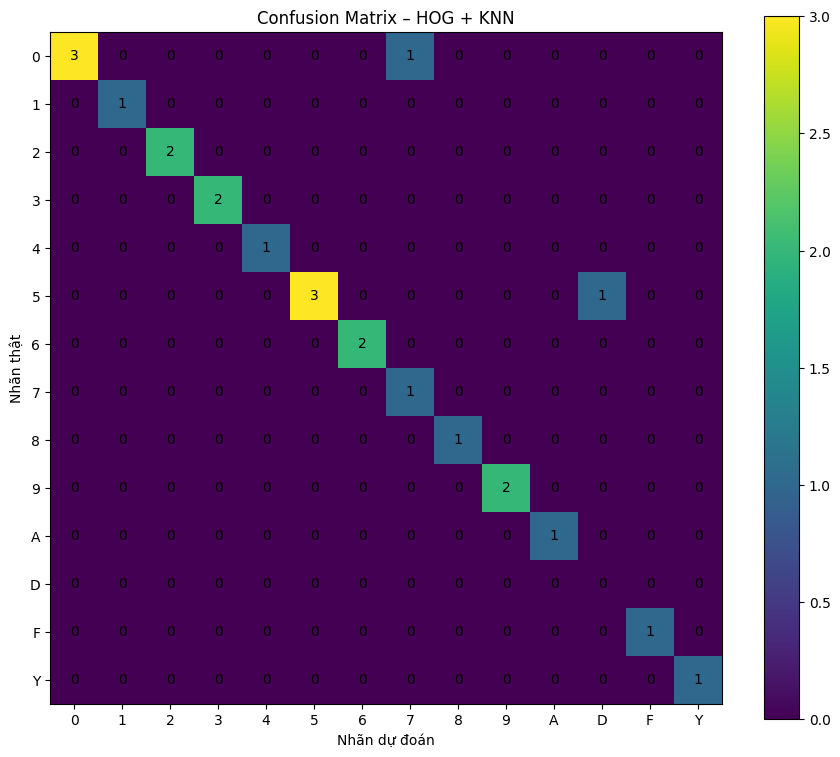

In [149]:
cm_labels, cm = confusion_matrix_manual(
    selected_y_true,
    selected_predictions,
)

cm_names = [
    chr(label)
    for label in cm_labels
]

cm_df = pd.DataFrame(
    cm,
    index=cm_names,
    columns=cm_names,
)

display(cm_df)

plt.figure(figsize=(
    max(7, len(cm_names) * 0.65),
    max(6, len(cm_names) * 0.55),
))

plt.imshow(cm)
plt.title(
    f"Confusion Matrix – "
    f"{selected_pipeline_name}"
)
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thật")
plt.xticks(
    range(len(cm_names)),
    cm_names,
)
plt.yticks(
    range(len(cm_names)),
    cm_names,
)
plt.colorbar()

for row_index in range(len(cm_names)):
    for column_index in range(
        len(cm_names)
    ):
        plt.text(
            column_index,
            row_index,
            cm[row_index, column_index],
            ha="center",
            va="center",
        )

plt.tight_layout()
plt.show()


## 25. Phân tích lỗi theo cặp ký tự và theo source


In [150]:
confusion_pairs = [
    (
        chr(true_label),
        chr(predicted_label),
    )
    for true_label, predicted_label
    in zip(
        selected_y_true,
        selected_predictions,
    )
    if true_label != predicted_label
]

confusion_pair_df = pd.DataFrame(
    Counter(confusion_pairs).most_common(),
    columns=[
        "Cặp nhầm (thật, dự đoán)",
        "Số lần",
    ],
)

display(confusion_pair_df)


,"Cặp nhầm (thật, dự đoán)",Số lần
0,"(0, 7)",1
1,"(5, D)",1


In [151]:
test_row_indices = (
    selected_final_object[
        "test_samples"
    ]["row_indices"]
)

test_details = (
    dataset_df
    .loc[test_row_indices]
    .copy()
)

test_details["Nhãn thật"] = [
    chr(value)
    for value in selected_y_true
]

test_details["Dự đoán"] = [
    chr(value)
    for value in selected_predictions
]

test_details["Đúng"] = (
    test_details["Nhãn thật"]
    == test_details["Dự đoán"]
)

wrong_details = test_details[
    ~test_details["Đúng"]
].copy()

display(wrong_details[[
    "image_path",
    "source_id",
    "Nhãn thật",
    "Dự đoán",
]])

source_error_summary = (
    test_details
    .groupby("source_id")
    .agg(
        Tong_mau=("Đúng", "size"),
        So_dung=("Đúng", "sum"),
    )
    .reset_index()
)

source_error_summary["So_sai"] = (
    source_error_summary["Tong_mau"]
    - source_error_summary["So_dung"]
)

source_error_summary["Ty_le_sai"] = (
    source_error_summary["So_sai"]
    / source_error_summary["Tong_mau"]
)

source_error_summary = (
    source_error_summary
    .sort_values(
        ["So_sai", "Ty_le_sai"],
        ascending=False,
    )
)

display(source_error_summary)


,image_path,source_id,Nhãn thật,Dự đoán
20,data/char_images/Tgmt_0305/char_02.png,Tgmt_0305,0,7
25,data/char_images/Tgmt_0305/char_07.png,Tgmt_0305,5,D


,source_id,Tong_mau,So_dung,So_sai,Ty_le_sai
0,Tgmt_0305,9,7,2,0.222222
1,carlong_0184,7,7,0,0.000000
2,carlong_0239,7,7,0,0.000000


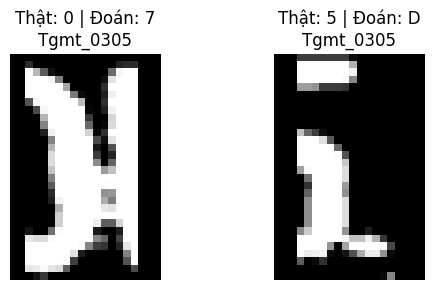

In [152]:
max_wrong_images = min(
    16,
    len(wrong_details),
)

if max_wrong_images:
    columns = min(4, max_wrong_images)
    rows = int(
        np.ceil(
            max_wrong_images / columns
        )
    )

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(
            3 * columns,
            3 * rows,
        ),
    )

    axes = np.asarray(
        axes
    ).reshape(-1)

    for ax, (_, row) in zip(
        axes,
        wrong_details
        .head(max_wrong_images)
        .iterrows(),
    ):
        image = cv2.imread(
            str(row["resolved_path"]),
            cv2.IMREAD_GRAYSCALE,
        )

        ax.imshow(image, cmap="gray")
        ax.set_title(
            f"Thật: {row['Nhãn thật']} | "
            f"Đoán: {row['Dự đoán']}\n"
            f"{row['source_id']}"
        )
        ax.axis("off")

    for ax in axes[max_wrong_images:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Không có mẫu dự đoán sai.")


## 26. Độ ổn định của cấu hình được chọn

Độ ổn định được lấy từ các validation fold đã dùng để chọn mô hình.

In [153]:
selected_mask = (
    (cv_results["Feature"]
        == selected_config["Feature"])
    & (cv_results["Model"]
        == selected_config["Model"])
    & (cv_results["Params"]
        == selected_config["Params"])
    & (
        cv_results["Augmentation"]
        == selected_config[
            "Augmentation"
        ]
    )
)

selected_stability = cv_results.loc[
    selected_mask,
    [
        "Seed",
        "Accuracy",
        "Macro F1",
        "Độ bao phủ lớp",
        "Sai",
    ],
].sort_values("Seed")

display(
    selected_stability.style.format({
        "Accuracy": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Độ bao phủ lớp": "{:.4f}",
    })
)

stability_summary = pd.DataFrame({
    "Chỉ số": [
        "Mean Accuracy",
        "Std Accuracy",
        "Mean Macro F1",
        "Std Macro F1",
        "Mean class coverage",
    ],
    "Giá trị": [
        selected_stability[
            "Accuracy"
        ].mean(),
        selected_stability[
            "Accuracy"
        ].std(ddof=1),
        selected_stability[
            "Macro F1"
        ].mean(),
        selected_stability[
            "Macro F1"
        ].std(ddof=1),
        selected_stability[
            "Độ bao phủ lớp"
        ].mean(),
    ],
})

display(
    stability_summary.style.format({
        "Giá trị": "{:.4f}",
    })
)


,Seed,Accuracy,Macro F1,Độ bao phủ lớp,Sai
66,7,0.9583,0.9833,0.6316,1
170,21,0.9583,0.9833,0.6316,1
274,42,0.9583,0.9833,0.6316,1
378,84,0.9583,0.9833,0.6316,1
482,99,0.9583,0.9833,0.6316,1


,Chỉ số,Giá trị
0,Mean Accuracy,0.9583
1,Std Accuracy,0.0000
2,Mean Macro F1,0.9833
3,Std Macro F1,0.0000
4,Mean class coverage,0.6316


## 27. Lưu model, scaler, metadata và báo cáo


In [154]:
cv_results.to_csv(
    REPORT_DIR / "cv_all_results.csv",
    index=False,
    encoding="utf-8",
)

selection_summary.to_csv(
    REPORT_DIR / "model_selection_summary.csv",
    index=False,
    encoding="utf-8",
)

best_four_validation.to_csv(
    REPORT_DIR / "best_four_validation.csv",
    index=False,
    encoding="utf-8",
)

final_test_results.to_csv(
    REPORT_DIR / "final_test_results.csv",
    index=False,
    encoding="utf-8",
)

per_class_report.to_csv(
    REPORT_DIR / "per_class_metrics.csv",
    index=False,
    encoding="utf-8",
)

cm_df.to_csv(
    REPORT_DIR / "confusion_matrix.csv",
    encoding="utf-8",
)

source_error_summary.to_csv(
    REPORT_DIR / "source_error_analysis.csv",
    index=False,
    encoding="utf-8",
)

selected_stability.to_csv(
    REPORT_DIR / "selected_model_stability.csv",
    index=False,
    encoding="utf-8",
)

audit_summary.to_csv(
    REPORT_DIR / "dataset_audit.csv",
    index=False,
    encoding="utf-8",
)

selected_model_path = (
    MODEL_DIR / "final_character_model.yml"
)

selected_scaler_path = (
    MODEL_DIR / "final_character_scaler.npz"
)

selected_metadata_path = (
    MODEL_DIR / "final_character_metadata.json"
)

selected_final_object["model"].save(
    str(selected_model_path)
)

np.savez(
    selected_scaler_path,
    mean=selected_final_object["mean"],
    std=selected_final_object["std"],
)

metadata = {
    "pipeline": selected_pipeline_name,
    "feature": (
        selected_config_dict["feature"]
    ),
    "feature_family": (
        selected_config_dict[
            "feature_family"
        ]
    ),
    "feature_dim": (
        selected_config_dict[
            "feature_dim"
        ]
    ),
    "model": selected_config_dict["model"],
    "augmentation": (
        selected_config_dict[
            "augmentation"
        ]
    ),
    "params_text": (
        selected_config_dict[
            "params_text"
        ]
    ),
    "k": selected_config_dict.get("k"),
    "C": selected_config_dict.get("C"),
    "gamma": selected_config_dict.get(
        "gamma"
    ),
    "char_size": list(CHAR_SIZE),
    "blur_kernel": BLUR_KERNEL,
    "cv_seeds": valid_fold_seeds,
    "final_test_seed": FINAL_TEST_SEED,
    "validation_mean_macro_f1": float(
        selected_config[
            "Mean_Macro_F1"
        ]
    ),
    "validation_std_macro_f1": float(
        selected_config[
            "Std_Macro_F1"
        ]
    ),
    "final_test_accuracy": float(
        selected_summary["Accuracy"]
    ),
    "final_test_macro_f1": float(
        selected_summary["Macro F1"]
    ),
    "final_test_class_coverage": float(
        selected_summary[
            "Độ bao phủ lớp"
        ]
    ),
    "dataset_labels": sorted(
        dataset_df["label"].unique().tolist()
    ),
    "missing_final_test_classes": (
        missing_final_test_classes
    ),
    "preprocessing": [
        "grayscale",
        "resize_20x30",
        f"gaussian_blur_{BLUR_KERNEL}x{BLUR_KERNEL}",
        "otsu_threshold",
        "white_character_black_background",
    ],
}

with selected_metadata_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Đã lưu model:", selected_model_path)
print("Đã lưu scaler:", selected_scaler_path)
print("Đã lưu metadata:", selected_metadata_path)
print("Đã lưu báo cáo:", REPORT_DIR)


Đã lưu model: f:\HocTap\xulyanh_thigiac\main\nh-n-bi-n-s-xe-main\model_data\final_character_model.yml
Đã lưu scaler: f:\HocTap\xulyanh_thigiac\main\nh-n-bi-n-s-xe-main\model_data\final_character_scaler.npz
Đã lưu metadata: f:\HocTap\xulyanh_thigiac\main\nh-n-bi-n-s-xe-main\model_data\final_character_metadata.json
Đã lưu báo cáo: f:\HocTap\xulyanh_thigiac\main\nh-n-bi-n-s-xe-main\model_data\experiment_reports


## 28. Dự đoán một thư mục ký tự bằng mô hình cuối


In [155]:
def natural_char_order(path):
    match = re.search(
        r"(\d+)",
        path.stem,
    )

    if match:
        return (
            0,
            int(match.group(1)),
            path.stem,
        )

    return (1, 0, path.stem)


def load_final_model():
    with selected_metadata_path.open(
        "r",
        encoding="utf-8",
    ) as file:
        metadata_loaded = json.load(file)

    scaler = np.load(
        selected_scaler_path
    )

    mean = scaler["mean"]
    std = scaler["std"]

    if metadata_loaded["model"] == "KNN":
        model = cv2.ml.KNearest_load(
            str(selected_model_path)
        )
    else:
        model = cv2.ml.SVM_load(
            str(selected_model_path)
        )

    return (
        model,
        mean,
        std,
        metadata_loaded,
    )


def predict_character_folder(folder):
    folder = Path(folder)

    image_paths = sorted(
        [
            path
            for path in folder.glob("char_*")
            if path.suffix.lower()
            in IMAGE_EXTENSIONS
        ],
        key=natural_char_order,
    )

    if not image_paths:
        raise ValueError(
            f"Không tìm thấy ảnh char_* trong {folder}"
        )

    model, mean, std, metadata_loaded = (
        load_final_model()
    )

    binaries = [
        preprocess_binary(
            path,
            blur_kernel=int(
                metadata_loaded[
                    "blur_kernel"
                ]
            ),
        )
        for path in image_paths
    ]

    X_raw = feature_matrix(
        binaries,
        metadata_loaded["feature"],
    )

    X_scaled = apply_scaler(
        X_raw,
        mean,
        std,
    )

    if metadata_loaded["model"] == "KNN":
        predictions = predict_knn(
            model,
            X_scaled,
            int(metadata_loaded["k"]),
        )
    else:
        predictions = predict_svm(
            model,
            X_scaled,
        )

    predicted_characters = [
        chr(value)
        for value in predictions
    ]

    predicted_text = "".join(
        predicted_characters
    )

    prediction_table = pd.DataFrame({
        "Ảnh": [
            str(path)
            for path in image_paths
        ],
        "Dự đoán": predicted_characters,
    })

    display(Markdown(
        f"## Kết quả nhận diện: `{predicted_text}`"
    ))
    display(prediction_table)

    return predicted_text, prediction_table


In [156]:
# Ví dụ:
# predicted_text, prediction_table = predict_character_folder(
#     r"data/char_images/thu_muc_bien_so_can_du_doan"
# )


## 29. Kết luận tự động


In [ ]:
selected_final_row = final_test_results[
    final_test_results["Pipeline"]
    == selected_pipeline_name
].iloc[0]

conclusion_text = (
    "### Kết luận thực nghiệm\n\n"
    f"- Cấu hình được chọn bằng repeated validation: "
    f"**{selected_pipeline_name}**.\n"
    f"- Feature cụ thể: "
    f"`{selected_config_dict['feature']}`.\n"
    f"- Tham số: "
    f"`{selected_config_dict['params_text']}`.\n"
    f"- Augmentation: "
    f"`{selected_config_dict['augmentation']}`.\n"
    f"- Validation Mean Macro F1: "
    f"`{selected_config['Mean_Macro_F1']:.4f}`.\n"
    f"- Final Test Accuracy: "
    f"`{selected_final_row['Accuracy']:.4f}`.\n"
    f"- Final Test Macro F1: "
    f"`{selected_final_row['Macro F1']:.4f}`.\n"
    f"- Final Test class coverage: "
    f"`{selected_final_row['Độ bao phủ lớp']:.4f}`.\n"
    f"- Majority baseline Macro F1: "
    f"`{baseline_summary['Macro F1']:.4f}`.\n"
    f"- Các lớp chưa xuất hiện trong final test: "
    f"`{missing_final_test_classes}`.\n\n"
    "Kết quả chỉ có giá trị trên dataset và quy trình "
    
)

display(Markdown(conclusion_text))


### Kết luận thực nghiệm

- Cấu hình được chọn bằng repeated validation: **HOG + KNN**.
- Feature cụ thể: `HOG6`.
- Tham số: `K=3`.
- Augmentation: `True`.
- Validation Mean Macro F1: `0.9833`.
- Validation Std Macro F1: `0.0000`.
- Final Test Accuracy: `0.9130`.
- Final Test Macro F1: `0.9524`.
- Final Test class coverage: `0.6842`.
- Majority baseline Macro F1: `0.0228`.
- Các lớp chưa xuất hiện trong final test: `['B', 'D', 'E', 'G', 'K', 'L']`.

Kết quả chỉ có giá trị trên dataset và quy trình đánh giá hiện tại. Những lớp không xuất hiện trong final test chưa được đánh giá đầy đủ.